In [ ]:
!pip install scikit-learn pandas numpy matplotlib

# ============================================================
# SECTION 1: SETUP & DATA LOADING
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    brier_score_loss, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from scipy.spatial.distance import cdist

warnings.filterwarnings("ignore")

df = pd.read_csv("academIQ_clean_dataset_v4.csv")
print("Shape:", df.shape)
print(df.head())

In [ ]:
# ============================================================
# SECTION 2: MULTI-TIER TARGET (Better Than Binary)
# ============================================================

def assign_performance_tier(grade):
    """
    Instead of binary high/not-high, used 4 tiers.
    This gives students a more nuanced, actionable picture
    and avoids the cliff-edge problem (74 (not HP) vs 75 is HP).
    """
    if grade >= 85:
        return 3   # Distinction
    elif grade >= 75:
        return 2   # High Performer
    elif grade >= 60:
        return 1   # Moderate Performer
    else:
        return 0   # At Risk

df["performance_tier"] = df["final_grade"].apply(assign_performance_tier)
df["high_performer"] = (df["final_grade"] >= 75).astype(int)

tier_labels = {0: "At Risk", 1: "Moderate", 2: "High Performer", 3: "Distinction"}
print("\nTier Distribution:")
print(df["performance_tier"].value_counts().sort_index().rename(tier_labels))

In [ ]:
# ============================================================
# SECTION 3: FEATURE ENGINEERING
# ============================================================

def engineer_features(df):
    """
    Add meaningful derived features. The goal is to capture
    behavioral patterns that raw features miss.
    """
    df = df.copy()

    # --- Efficiency Features ---
    # Are clicks translating into outcomes?
    df["clicks_per_day"] = df["all_clicks"] / (df["active_days"] + 1)
    df["time_per_click"] = df["total_time_spent"] / (df["all_clicks"] + 1)

    # --- Consistency Features ---
    # Measures regularity vs. binge-studying
    df["engagement_consistency"] = df["active_days"] / (df["total_time_spent"] / 60 + 1)

    # --- Assessment Performance ---
    # Include these — they're strong signals
    df["assessment_avg"] = (df["avg_quiz_score"] + df["avg_assignment_score"]) / 2
    df["quiz_efficiency"] = df["avg_quiz_score"] / (df["quiz_attempts"] + 1)

    # --- Risk Composite Score ---
    # Normalize procrastination and late submissions together
    df["behavioral_risk_score"] = (
        df["procrastination_index"].clip(lower=0) * 0.6 +
        df["late_submission_count"] * 10 * 0.4
    )

    # --- Relative Performance (vs. class median) ---
    for col in ["all_clicks", "total_time_spent", "active_days"]:
        median_val = df[col].median()
        df[f"{col}_relative"] = df[col] / (median_val + 1)

    return df

df = engineer_features(df)

# Define feature sets
# BEHAVIORAL: things students can directly change
behavioral_features = [
    "all_clicks", "active_days", "access_frequency",
    "material_clicks", "quiz_attempts", "assignment_submissions",
    "total_time_spent", "procrastination_index", "late_submission_count",
    "clicks_per_day", "engagement_consistency", "behavioral_risk_score",
    "all_clicks_relative", "total_time_spent_relative", "active_days_relative"
]

# FULL: includes assessment scores (for maximum predictive power)
full_features = behavioral_features + [
    "avg_quiz_score", "avg_assignment_score",
    "assessment_avg", "quiz_efficiency"
]

print(f"Behavioral features: {len(behavioral_features)}")
print(f"Full features: {len(full_features)}")

In [4]:
# ============================================================
# SECTION 4: MODEL COMPARISON & SELECTION
# ============================================================

X = df[full_features]
y = df["high_performer"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Class balance (train): {y_train.mean():.2%} high performers")

# --- Define candidate models ---
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=400, max_depth=8,
        min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", random_state=42,
        use_label_encoder=False, verbosity=0
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("\n--- Cross-Validation Results ---")
for name, model in models.items():
    cv_auc = cross_val_score(model, X_train, y_train, cv=cv,
                              scoring="roc_auc", n_jobs=-1)
    cv_brier = cross_val_score(model, X_train, y_train, cv=cv,
                                scoring="neg_brier_score", n_jobs=-1)
    results[name] = {
        "ROC-AUC (mean)": cv_auc.mean(),
        "ROC-AUC (std)": cv_auc.std(),
        "Brier Score (mean)": -cv_brier.mean()
    }
    print(f"\n{name}:")
    print(f"  ROC-AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
    print(f"  Brier Score: {-cv_brier.mean():.4f} (lower = better calibration)")

results_df = pd.DataFrame(results).T
print("\n--- Summary ---")
print(results_df.round(4))

Train size: 14034, Test size: 3509
Class balance (train): 9.90% high performers

--- Cross-Validation Results ---

Random Forest:
  ROC-AUC: 0.9280 ± 0.0033
  Brier Score: 0.0553 (lower = better calibration)

XGBoost:
  ROC-AUC: 0.9273 ± 0.0039
  Brier Score: 0.0597 (lower = better calibration)

LightGBM:
  ROC-AUC: 0.9264 ± 0.0045
  Brier Score: 0.0594 (lower = better calibration)

--- Summary ---
               ROC-AUC (mean)  ROC-AUC (std)  Brier Score (mean)
Random Forest          0.9280         0.0033              0.0553
XGBoost                0.9273         0.0039              0.0597
LightGBM               0.9264         0.0045              0.0594


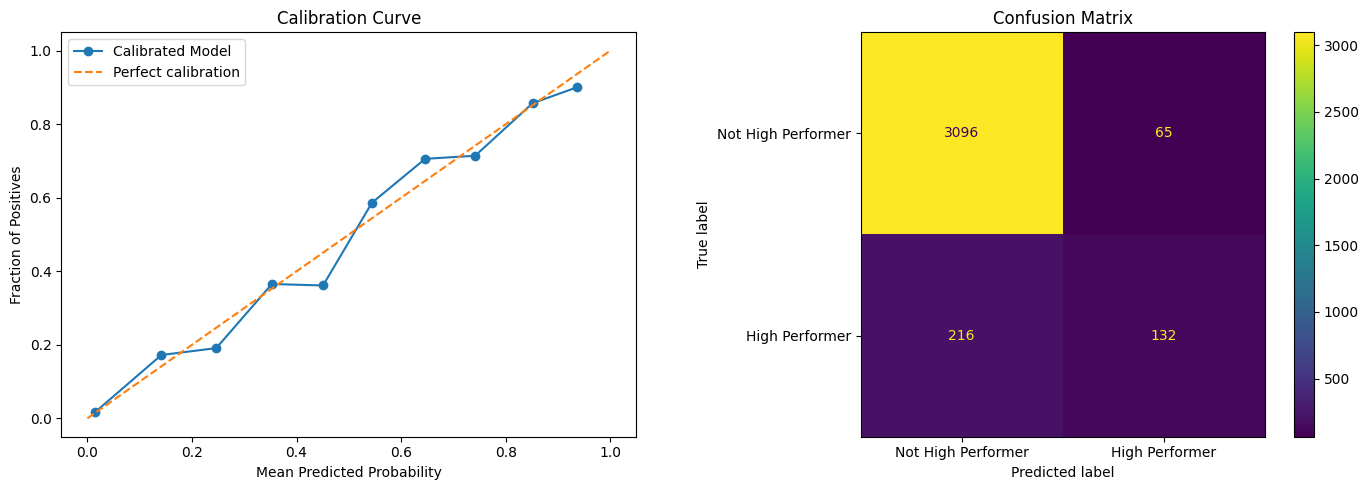


Accuracy:    0.9199
ROC-AUC:     0.9184
Brier Score: 0.0594

Classification Report:
                    precision    recall  f1-score   support

Not High Performer       0.93      0.98      0.96      3161
    High Performer       0.67      0.38      0.48       348

          accuracy                           0.92      3509
         macro avg       0.80      0.68      0.72      3509
      weighted avg       0.91      0.92      0.91      3509



In [5]:
# ============================================================
# SECTION 5: PROBABILITY CALIBRATION (Critical for Student Scores)
# ============================================================

# Train the best-performing model (update based on Section 4 results)
best_model = lgb.LGBMClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1
)

# Calibrate: this makes probability=0.7 actually mean 70% likely
calibrated_model = CalibratedClassifierCV(
    best_model, method="isotonic", cv=5
)
calibrated_model.fit(X_train, y_train)

# Evaluate calibration
prob_true, prob_pred = calibration_curve(
    y_test,
    calibrated_model.predict_proba(X_test)[:, 1],
    n_bins=10
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration curve
axes[0].plot(prob_pred, prob_true, marker='o', label='Calibrated Model')
axes[0].plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
axes[0].set_xlabel("Mean Predicted Probability")
axes[0].set_ylabel("Fraction of Positives")
axes[0].set_title("Calibration Curve")
axes[0].legend()

# Confusion matrix
disp = ConfusionMatrixDisplay.from_estimator(
    calibrated_model, X_test, y_test,
    display_labels=["Not High Performer", "High Performer"],
    ax=axes[1]
)
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

# Final metrics
y_pred = calibrated_model.predict(X_test)
y_proba = calibrated_model.predict_proba(X_test)[:, 1]

print(f"\nAccuracy:    {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:     {roc_auc_score(y_test, y_proba):.4f}")
print(f"Brier Score: {brier_score_loss(y_test, y_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=["Not High Performer", "High Performer"]))

SHAP values shape: (3509, 19)


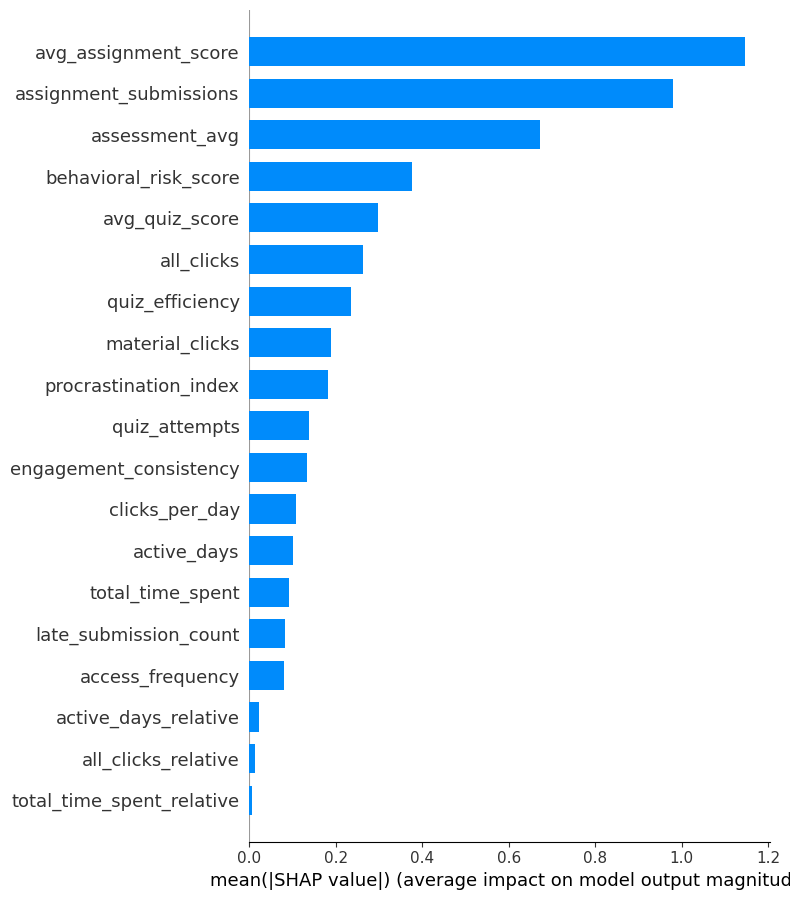

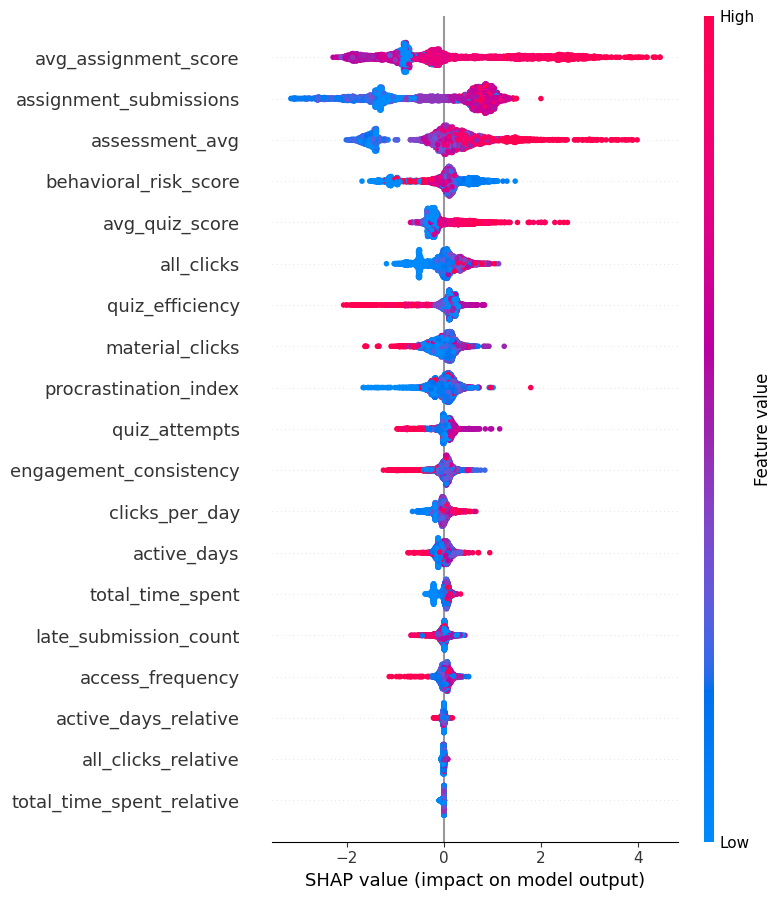

In [6]:
# ============================================================
# SECTION 6: SHAP ANALYSIS (Properly Structured)
# ============================================================

# For SHAP, use the underlying uncalibrated model
# (CalibratedClassifierCV wraps the model, making SHAP harder)
best_model.fit(X_train, y_train)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values is a list [class_0, class_1]
if isinstance(shap_values, list):
    shap_values_positive = shap_values[1]
else:
    shap_values_positive = shap_values

print("SHAP values shape:", shap_values_positive.shape)

# Global feature importance
shap.summary_plot(shap_values_positive, X_test, plot_type="bar",
                  title="Global Feature Importance (SHAP)")

# Beeswarm plot for direction of impact
shap.summary_plot(shap_values_positive, X_test,
                  title="SHAP Feature Impact Direction")

In [8]:
# ============================================================
# SECTION 7: COUNTERFACTUAL RECOMMENDATIONS
# This replaces the flawed "simulate random improvements" approach.
# Instead: find the SMALLEST change to flip classification.
# ============================================================

def find_counterfactual(
    student_index,
    model,
    X_test,
    feature_names,
    X_train_ref,
    step_size=0.05,
    max_iter=100
):
    """
    Find the minimum behavioral changes needed to flip a student's
    classification from 'Not High Performer' to 'High Performer'.

    Method: Gradient-free search. For each mutable behavioral feature,
    incrementally move toward the value seen in high-performer training
    examples until the prediction flips.

    This is conceptually honest — it shows the DIRECTION and
    MAGNITUDE of change needed, not a magical override.
    """
    student_data = X_test.iloc[student_index].copy()
    current_prob = model.predict_proba([student_data])[0][1]
    current_class = int(current_prob >= 0.5)

    if current_class == 1:
        return {
            "status": "Already classified as High Performer",
            "probability": round(current_prob, 3),
            "changes_needed": {}
        }

    # Reference: what do high performers look like on average?
    high_performer_train_mask = model.predict(X_train_ref) == 1
    high_performer_means = X_train_ref[high_performer_train_mask].mean()

    # Only allow changes to BEHAVIORAL features (not assessment scores)
    mutable_features = [
        f for f in feature_names
        if f not in ["avg_quiz_score", "avg_assignment_score",
                     "assessment_avg", "quiz_efficiency"]
    ]

    modified_data = student_data.copy()
    changes_made = {}

    for iteration in range(max_iter):
        current_prob = model.predict_proba([modified_data])[0][1]
        if current_prob >= 0.5:
            break

        # Move each mutable feature toward high-performer average
        best_gain = 0
        best_feature = None
        best_value = None

        for feature in mutable_features:
            if feature not in modified_data.index:
                continue

            target_value = high_performer_means.get(feature, modified_data[feature])
            current_value = modified_data[feature]

            if abs(target_value - current_value) < 1e-6:
                continue

            # Simulate a small step toward the target
            direction = np.sign(target_value - current_value)
            step = direction * step_size * abs(target_value - current_value)
            test_data = modified_data.copy()
            test_data[feature] = current_value + step

            new_prob = model.predict_proba([test_data])[0][1]
            gain = new_prob - current_prob

            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_value = test_data[feature]

        if best_feature is None or best_gain < 1e-6:
            break

        # Apply the best single-feature improvement
        if best_feature not in changes_made:
            changes_made[best_feature] = {"original": float(modified_data[best_feature])}

        modified_data[best_feature] = best_value
        changes_made[best_feature]["suggested"] = float(best_value)

    final_prob = model.predict_proba([modified_data])[0][1]
    flipped = final_prob >= 0.5

    return {
        "status": "Flip achieved ✅" if flipped else "Partial improvement (flip not achieved with available features)",
        "original_probability": round(current_prob, 3),
        "new_probability": round(final_prob, 3),
        "probability_gain": round(final_prob - current_prob, 3),
        "changes_needed": {
            k: {
                "from": round(v["original"], 3),
                "to": round(v["suggested"], 3),
                "change": round(v["suggested"] - v["original"], 3)
            }
            for k, v in changes_made.items()
        }
    }

In [9]:
# ============================================================
# SECTION 8: HONEST STUDENT RECOMMENDATIONS
# ============================================================

# Actionable advice per feature with clear reasoning
RECOMMENDATION_MAP = {
    "procrastination_index": {
        "icon": "⏰",
        "short": "Procrastination is your biggest hurdle",
        "action": "Break assignments into daily micro-tasks. Use the 2-minute rule: if a task takes under 2 minutes, do it now.",
        "why": "High procrastination is the #1 behavioral predictor of low performance in your cohort."
    },
    "late_submission_count": {
        "icon": "📅",
        "short": "Late submissions are costing you",
        "action": "Set personal deadlines 48 hours before the official deadline. Enable calendar reminders.",
        "why": "Each late submission significantly reduces your probability of high performance."
    },
    "access_frequency": {
        "icon": "🔄",
        "short": "Access the platform more regularly",
        "action": "Log in at least once daily, even for 10 minutes. Consistency beats marathon sessions.",
        "why": "Students who access the platform regularly outperform sporadic learners, even with the same total time."
    },
    "total_time_spent": {
        "icon": "🕐",
        "short": "Increase your study time",
        "action": "Add two 30-minute focused sessions per week. Use the Pomodoro technique.",
        "why": "You're spending significantly less time than high performers in your cohort."
    },
    "quiz_attempts": {
        "icon": "📝",
        "short": "Practice quizzes more",
        "action": "Attempt every available quiz at least twice — first without notes, then with. Focus on wrong answers.",
        "why": "Active recall through quizzes is one of the most evidence-backed learning strategies."
    },
    "material_clicks": {
        "icon": "📚",
        "short": "Engage more with course materials",
        "action": "Read each module's materials before attempting assignments. Note key concepts.",
        "why": "Limited material interaction suggests gaps in foundational knowledge."
    },
    "active_days": {
        "icon": "📆",
        "short": "Spread your study across more days",
        "action": "Study 5 days a week for 30 minutes rather than 2 days for 75 minutes.",
        "why": "Spaced repetition — studying across days — dramatically improves long-term retention."
    },
    "assignment_submissions": {
        "icon": "📤",
        "short": "Submit all assignments",
        "action": "Prioritize completing all assignments even if they're not perfect. A submitted assignment always scores better than none.",
        "why": "Missing assignments compound into significant grade drops."
    },
    "behavioral_risk_score": {
        "icon": "⚠️",
        "short": "High behavioral risk detected",
        "action": "Address procrastination and late submissions together — they compound each other.",
        "why": "Your combined behavioral risk score places you in the bottom quartile of your cohort."
    },
    "engagement_consistency": {
        "icon": "📊",
        "short": "Improve engagement consistency",
        "action": "Avoid binge-studying before deadlines. Build a regular weekly schedule.",
        "why": "Consistent engagement predicts performance better than total time spent."
    }
}

def generate_recommendations(
    student_index,
    model,
    shap_values_positive,
    X_test,
    top_k=3,
    confidence_threshold=0.85
):
    """
    Generate honest, actionable recommendations.

    Key design decisions:
    - Only recommend changing BEHAVIORAL features (things the student controls)
    - Show uncertainty when the model isn't confident
    - Prioritize by SHAP magnitude, not just sign
    - Give context (how far from the median)
    """
    student_data = X_test.iloc[student_index]
    student_shap = shap_values_positive[student_index]
    probability = calibrated_model.predict_proba([student_data])[0][1]

    # Honest uncertainty handling
    if 0.4 <= probability <= 0.6:
        confidence_note = (
            "⚠️ Note: The model is uncertain about this prediction. "
            "These recommendations are directional, not definitive."
        )
    else:
        confidence_note = None

    # Get SHAP contributions for behavioral features only
    behavioral_only = [f for f in full_features if f in behavioral_features]
    shap_contributions = {}

    for i, feature in enumerate(full_features):
        if feature in behavioral_only:
            shap_contributions[feature] = float(student_shap[i])

    # Sort by most negative contribution
    sorted_features = sorted(
        shap_contributions.items(), key=lambda x: x[1]
    )

    # Build recommendations
    recommendations = []
    features_addressed = []

    for feature, shap_val in sorted_features:
        if shap_val >= 0:
            continue  # Skip features that are already helping
        if feature not in RECOMMENDATION_MAP:
            continue
        if len(recommendations) >= top_k:
            break

        rec = RECOMMENDATION_MAP[feature].copy()

        # Add context: how far from median?
        feature_value = float(student_data[feature])
        median_value = float(X_test[feature].median())
        percentile = int(
            (X_test[feature] <= feature_value).mean() * 100
        )

        rec["feature"] = feature
        rec["your_value"] = round(feature_value, 2)
        rec["median_value"] = round(median_value, 2)
        rec["percentile"] = percentile
        rec["shap_impact"] = round(shap_val, 4)

        recommendations.append(rec)
        features_addressed.append(feature)

    if not recommendations:
        recommendations.append({
            "icon": "✅",
            "short": "No major behavioral issues detected",
            "action": "Maintain your current engagement. Focus on deepening content understanding.",
            "why": "Your behavioral patterns align with high performers."
        })

    return {
        "student_index": student_index,
        "probability": round(probability, 3),
        "classification": "High Performer 🎯" if probability >= 0.5 else "Not Yet High Performer",
        "confidence_note": confidence_note,
        "top_negative_drivers": features_addressed,
        "recommendations": recommendations
    }


def display_recommendations(rec_dict):
    """Pretty print the recommendations."""
    print("=" * 60)
    print(f"STUDENT PERFORMANCE REPORT")
    print("=" * 60)
    print(f"Classification:  {rec_dict['classification']}")
    print(f"Probability:     {rec_dict['probability']:.1%}")

    if rec_dict.get("confidence_note"):
        print(f"\n{rec_dict['confidence_note']}")

    print(f"\n📌 Key Areas for Improvement:")
    for i, rec in enumerate(rec_dict["recommendations"], 1):
        print(f"\n{i}. {rec['icon']} {rec['short']}")
        if "your_value" in rec:
            print(f"   Your value: {rec['your_value']} (class median: {rec['median_value']}, "
                  f"you're at the {rec['percentile']}th percentile)")
        print(f"   ➤ {rec['action']}")
        print(f"   💡 Why: {rec['why']}")
    print("=" * 60)

In [10]:
# ============================================================
# SECTION 9: PROGRESS TRACKING (Honest Version)
# ============================================================

def track_real_progress(
    student_index_or_data,
    new_actual_data,
    model,
    shap_values_ref,
    X_test,
    is_index=True
):
    """
    Track REAL behavioral changes, not simulated ones.

    The key difference from the original: this is meant to be called
    with ACTUAL new data from the student (next week's logged activity),
    not simulated "what if" values.

    Parameters:
        student_index_or_data: either an index into X_test, or a raw feature dict
        new_actual_data: dict of feature_name -> actual_new_value
        is_index: whether first arg is an index (True) or raw data (False)
    """
    if is_index:
        original_data = X_test.iloc[student_index_or_data].copy()
    else:
        original_data = pd.Series(student_index_or_data)

    old_prob = calibrated_model.predict_proba([original_data])[0][1]

    updated_data = original_data.copy()
    for feature, value in new_actual_data.items():
        if feature in updated_data.index:
            updated_data[feature] = value

    new_prob = calibrated_model.predict_proba([updated_data])[0][1]

    # What changed and in which direction?
    changes_summary = []
    for feature, new_val in new_actual_data.items():
        if feature in original_data.index:
            old_val = original_data[feature]
            direction = "↑" if new_val > old_val else "↓" if new_val < old_val else "→"
            changes_summary.append({
                "feature": feature,
                "from": round(float(old_val), 3),
                "to": round(float(new_val), 3),
                "direction": direction
            })

    improvement = new_prob - old_prob

    return {
        "old_probability": round(old_prob, 3),
        "new_probability": round(new_prob, 3),
        "improvement": round(improvement, 3),
        "old_classification": "High Performer" if old_prob >= 0.5 else "Not High Performer",
        "new_classification": "High Performer" if new_prob >= 0.5 else "Not High Performer",
        "status": "📈 Improving" if improvement > 0.02 else
                  "📉 Declining" if improvement < -0.02 else "➡️ Stable",
        "changes": changes_summary
    }

In [11]:
# ============================================================
# SECTION 10: SAVE ALL ARTIFACTS
# ============================================================

joblib.dump(calibrated_model, "performance_model_calibrated.pkl")
joblib.dump(best_model, "performance_model_raw.pkl")   # For SHAP
joblib.dump(full_features, "feature_list_full.pkl")
joblib.dump(behavioral_features, "feature_list_behavioral.pkl")
joblib.dump(explainer, "shap_explainer.pkl")

print("All model artifacts saved.")

# ============================================================
# SECTION 11: EXAMPLE USAGE
# ============================================================

# Generate recommendations for a student
rec = generate_recommendations(
    student_index=5,
    model=best_model,
    shap_values_positive=shap_values_positive,
    X_test=X_test,
    top_k=3
)
display_recommendations(rec)

# Find counterfactual (minimum change to flip classification)
print("\n--- Counterfactual Analysis ---")
cf = find_counterfactual(
    student_index=5,
    model=best_model,
    X_test=X_test,
    feature_names=full_features,
    X_train_ref=X_train
)
print(f"Status: {cf['status']}")
print(f"Probability: {cf['original_probability']} → {cf['new_probability']}")
print("Changes needed:")
for feature, change in cf["changes_needed"].items():
    print(f"  {feature}: {change['from']} → {change['to']} ({change['change']:+.3f})")

# Track real progress
print("\n--- Progress Tracking ---")
progress = track_real_progress(
    student_index_or_data=5,
    new_actual_data={
        "procrastination_index": 0.2,
        "late_submission_count": 0,
        "quiz_attempts": 12
    },
    model=best_model,
    shap_values_ref=shap_values_positive,
    X_test=X_test
)
print(f"Status: {progress['status']}")
print(f"Probability: {progress['old_probability']} → {progress['new_probability']}")
print(f"Net change: {progress['improvement']:+.3f}")

All model artifacts saved.
STUDENT PERFORMANCE REPORT
Classification:  Not Yet High Performer
Probability:     0.0%

📌 Key Areas for Improvement:

1. 📤 Submit all assignments
   Your value: 0.0 (class median: 5.0, you're at the 14th percentile)
   ➤ Prioritize completing all assignments even if they're not perfect. A submitted assignment always scores better than none.
   💡 Why: Missing assignments compound into significant grade drops.

2. ⚠️ High behavioral risk detected
   Your value: 0.0 (class median: 12.0, you're at the 12th percentile)
   ➤ Address procrastination and late submissions together — they compound each other.
   💡 Why: Your combined behavioral risk score places you in the bottom quartile of your cohort.

3. 🕐 Increase your study time
   Your value: 98.0 (class median: 1126.0, you're at the 8th percentile)
   ➤ Add two 30-minute focused sessions per week. Use the Pomodoro technique.
   💡 Why: You're spending significantly less time than high performers in your cohort.